In [161]:
import math
import numpy as np
import matplotlib.pyplot as plt
import Tiamat as tiam

c:\Users\famig\Desktop\metcomp\Tiamat.py:60: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel(r'I [$\mu$A]', size=14)


In [162]:
b = 8/3
sigma = 10
r = 28


N=20000
nt = 1000
DT = 3*math.pi/nt

In [163]:
def g(state,t):
    x,y,z = state[0],state[1],state[2]

    v = np.zeros(3)
    v[0] = sigma*(y-x)
    v[1] = r*x-y-x*z
    v[2] = x*y- b*z
    return v

def rungeKutta(y, t, dt):
    C1 = g(y, t)
    C2 = g(y + dt*C1/2, t + dt/2)
    C3 = g(y + dt*C2/2, t + dt/2)
    C4 = g(y + dt*C3,   t + dt)
    return y + dt*(C1 + 2*C2 + 2*C3 + C4)/6

def esperimento(x0,y0,z0):
    X1 = np.zeros(N+1)
    Y1 = np.zeros(N+1)
    Z1 = np.zeros(N+1)

    Y = np.array([x0,y0,z0])
    for i in range(N):
        t = DT*i
        Y = rungeKutta(Y,t,DT)
        X1[i+1] = Y[0]
        Y1[i+1] = Y[1]
        Z1[i+1] = Y[2]
    

    fig = plt.figure(figsize=(10,10))  
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X1, Y1, Z1, c=np.arange(N+1), cmap='coolwarm', marker='o')
    plt.show()

    return X1,Y1,Z1

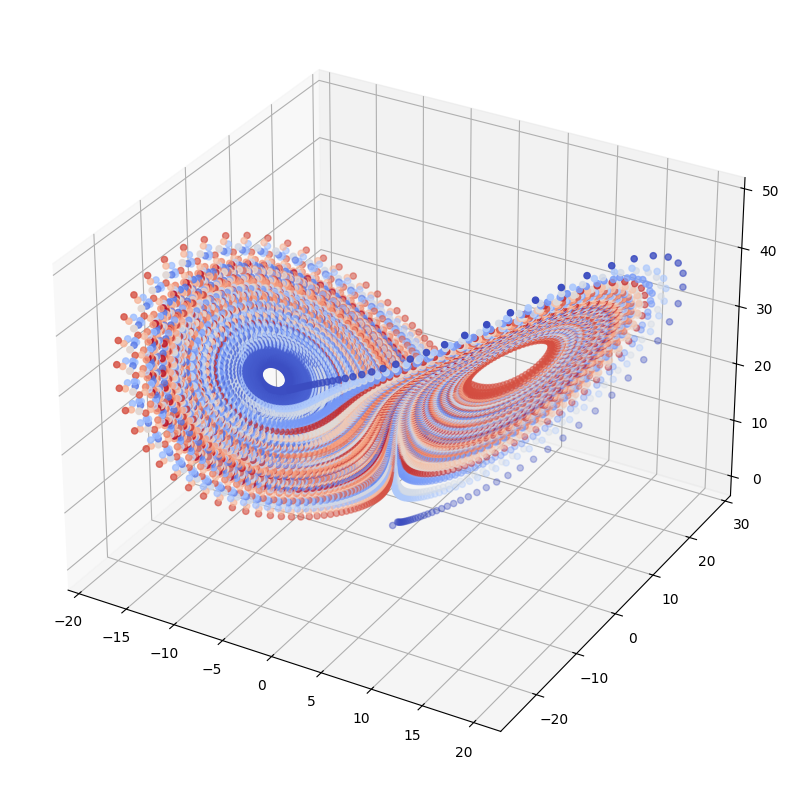

In [164]:
X0,Y0,Z0 = esperimento(0,1,0)

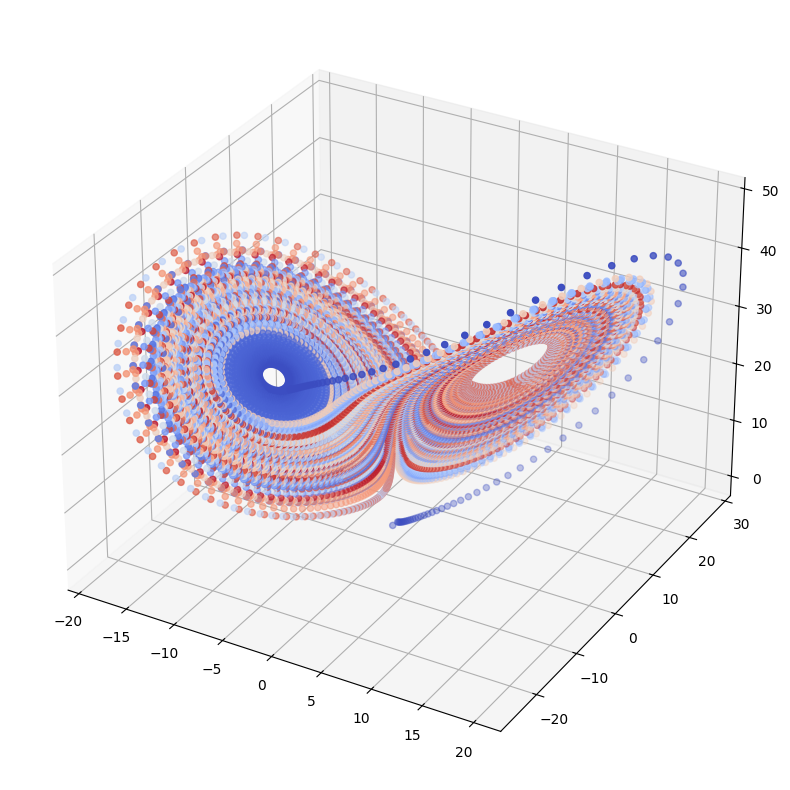

In [165]:
DIFFY = 1e-7
X1,Y1,Z1=esperimento(0,1+DIFFY,0)

C:\Users\famig\AppData\Local\Temp\ipykernel_4832\2846500353.py:10: RuntimeWarning: divide by zero encountered in log
  DIST = np.log(DIST)


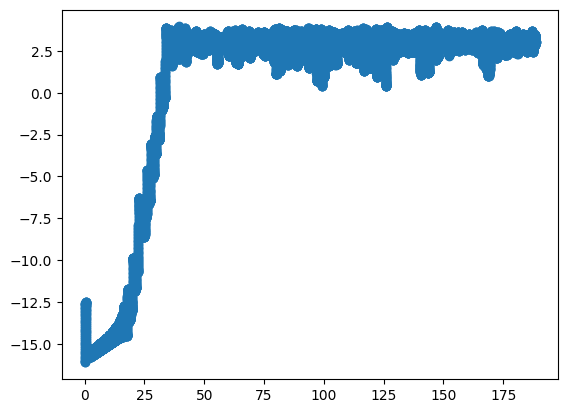

timehorizion:  188.4861344374268
Slope: 1.0531090077056695, Intercept: -34.13036461461532
Matrice di covarianza:
[[ 6.32837966e-05 -1.59969481e-06]
 [-1.59969481e-06  5.57090247e-02]]
massimo coefficiente di lyapunov:  1.0531090077056695


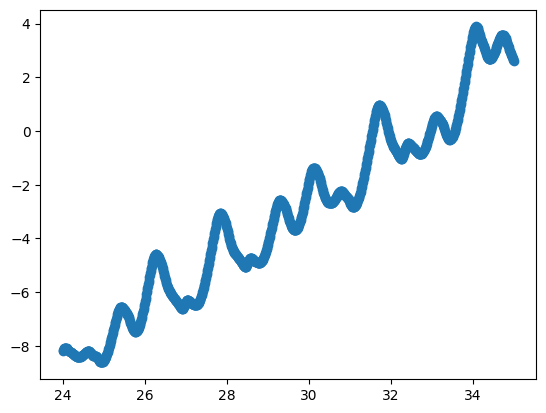

In [166]:
DIST = np.zeros(N + 1)
tempi = np.zeros(N + 1)

for i in range(N):
    tempi[i] = DT*i
    DIST[i] = math.sqrt((X1[i] - X0[i])**2 + 
                     (Y1[i] - Y0[i])**2 +
                     (Z1[i] - Z0[i])**2)
      
DIST = np.log(DIST)
plt.scatter(tempi,DIST)
plt.show()



timehorizon = 0
for i in range(N):
    if DIST[i] >= 0.001:
        timehorizon = i*DT
print("timehorizion: ", timehorizon)


mask = (tempi >= 24) & (tempi <= 35)
X_sel = tempi[mask]
Y_sel = DIST[mask]

plt.scatter(X_sel,Y_sel)
slope, intercept, cov_matrix = tiam.fit_lineare(X_sel,Y_sel)
print("massimo coefficiente di lyapunov: ", slope)
